# How to calculate the vorticity of a 2D field

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

We consider the domain $\Omega = (0,1) \times (0,1)$, and discretize with triangular elements. The 2D velocity field is a $P2$ finite element vector field and the magnitude of the vorticity has been stored in a $P2$ finite element scalar field. 

In [7]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName, meshFileName)

scalarSpace = createFunctionSpace(mesh, degree=2, dim=1)
vectorSpace = createFunctionSpace(mesh, degree=2, dim=2)

phiVec = Field(vectorSpace, mesh=mesh, name="function_2d")
phiVec.importData(Reader(), "input")


Info     | FELiCSMesh.py          | __init__                   (line 94  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 102 ) : Mesh contains 513 nodes and 1024 elements


(<FELiCS.Fields.Field.Field at 0x7ca0d41542d0>, [])

**Step 2: Computing the vorticity and comparison with the analytical results.**

For a 2D velocity field given by $\vec{\textbf{u}} = (u, v)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = (\frac{\partial u}{\partial y} - \frac{\partial v}{\partial x}) \hat{z},
$$

where $\hat{x}, \hat{y}, \hat{z}$, represent the unit vectors along the Cartesian coordinate axes in 3D space. However, for a 3D velocity field given by $\vec{\textbf{u}} = (u, v, w)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = \left( \frac{\partial w}{\partial y} - \frac{\partial v}{\partial z} \right) \hat{x}
+
\left( \frac{\partial u}{\partial z} - \frac{\partial w}{\partial x} \right) \hat{y}
+
\left( \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} \right) \hat{z}
$$



<!-- We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field.
To verify the solution we also calculate the gradient manually. -->

In [8]:
vorticity = phiVec.getVorticityField()

**Step3. Postprocessing via plotting contour plots**

We plot two 2D color plots of the velocity and vorticity magnitudes respectively.

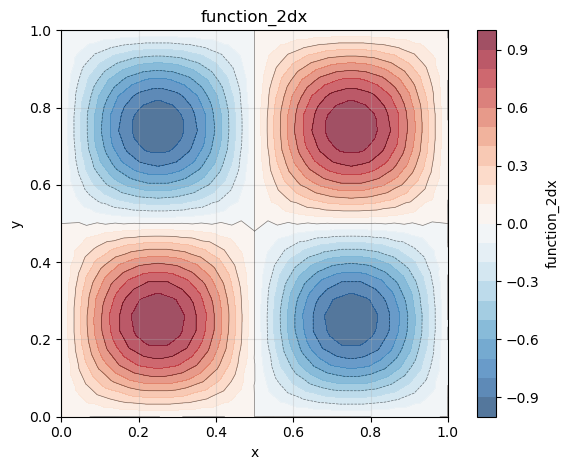

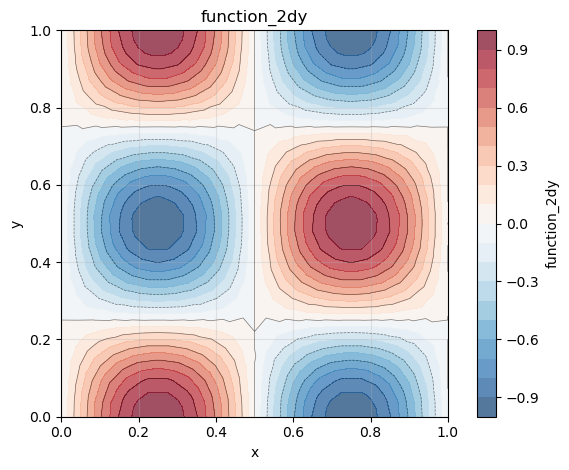

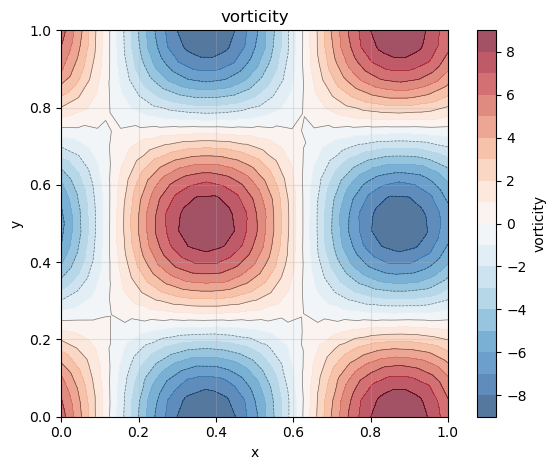

In [10]:
[phi_x, phi_y] = phiVec.getListOfSubFields()

phi_x.plot()
phi_y.plot()
vorticity.plot()
